----------------------------------------------------------------------------------------------------

# ***Boas práticas em consultas SQL - SQLite***

Ao escrever consultas SQL em Python, é importante seguir boas práticas para garantir a segurança e a eficiência do seu código.

----------------------------------------------------------------------------------------------------

# ***1. Pensando em Segurança*** 

Uma dessas práticas é evitar a concatenação de strings nas consultas e usar consultas parametrizadas. Isso não apenas melhora a legibilidade do código, mas também ajuda a previnir ataques de injeção SQL.

Exemplo:

***NÃO faça isso:***

In [ ]:
id = 1
cursor.execute('SELECT * FROM minha_tabela WHERE id = ' + str(id))

***Faça isso:***

In [ ]:
id = 1
cursor.execute('SELECT * FROM minha_tabela WHERE id = ', (id, ))

## ***1.1. Exemplo mais detalhado***

In [ ]:
id_cliente = input("Informe o id do cliente: ")
cur.execute(f"SELECT * FROM clientes WHERE id = {id_cliente}")
cliente = cur.fetchone()
print(dict(cliente))

No exemplo que fizemos acima, criamos um programa que permiti o usuário a definir um número id e então, o programa retorna qual é os valores que aquele id pode nos dar, segundo a sua tabela. 

Porém, pelo fato de eu ter feito o código com concatenação:

In [ ]:
cur.execute(f"SELECT * FROM clientes WHERE id = {id_cliente}")

É nessa parte que esta o problema.

O SQL irá receber o id e, se ele existir (ou seja é True) ele retorna o valor.

Mas suponhamos que o usuário é mal-intencionado e queira ter acesso a algum outro id que não foi o que ele descreveu.

Ele pode, durante a declaração do id for pedida pela função input(), colocar algo como:

1 OR 1 = 1;

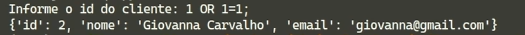

O id informado foi '1', porém o SQL retornou o id '2'.

Explicação:
- Embora o usuário tenha mencionado o id '1' logo no início, ele também criou sem necessidade uma situação bool, em que ele dá o número '1', mas já informa ao SQL que é isso OU (OR) 1 é igual a 1. Por motivos óbvios, o SQL dará TRUE, ambas são respostas corretas, mas ele entra em um tipo de bug e retorna um valor, mas não o pedido e sim retorna um outro valor. Um grave erro de segurança.

## ***1.2. Agora imagine se usarmos o 'fetchall()'***

No nosso código acima, usamos o método fetchone(), portanto foi por conta dele que apenas um valor foi retornado:

In [ ]:
cliente = cur.fetchone()

Mas e se fosse assim:

In [ ]:
clientes = cur.fetchall()
for cliente in clientes:
    print(dict(cliente))

Resultado:

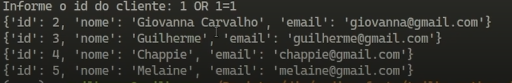

Agora, se tivessemos usado o 'fetchall()', ***toda a nossa tabela que é acessada por aquele 'id' do nosso banco de dados teria sido retornado ao usuário mal-intensionado!***

***Tudo isso é causado por conta da concatenaçao!***

----------------------------------------------------------------------------------------------------

# ***2. Solução*** 

O método correto é o que nós fizemos em todo esse projeto desse repositório:

In [ ]:
id_cliente = input("Informe o id do cliente: ")
cur.execute(f"SELECT * FROM clientes WHERE id = ?", (id_cliente, ))
cliente = cur.fetchone()
print(dict(cliente))

Dessa forma, o próprio Python irá 'tratar' o código pra gente. O que ele não aceitará o resultado e fará o resultado ser 'None'.

----------------------------------------------------------------------------------------------------